### Cell 1: Imports and connect to MongoDB

In [8]:
import sys
sys.path.append("..")  # so we can import from src/ (notebook is inside notebooks/)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, db

sns.set_style("whitegrid")
%matplotlib inline

### Cell 2: Load data from MongoDB into a DataFrame

In [9]:
client = db.get_client()
collection = db.get_collection(config.FEATURES_COLLECTION, client)

# Pull every document for our city, sorted by time
cursor = collection.find({"city": config.CITY_NAME}).sort("timestamp", 1)
df = pd.DataFrame(list(cursor))

client.close()

print(df.shape)
df.head()

(17544, 23)


,_id,hour_bucket,city,aqi,aqi_change_rate,co,day,day_of_week,hour,humidity,...,nh3,no2,o3,pm10,pm2_5,pressure,so2,temperature,timestamp,wind_speed
0,6a5f28c54d719641b4be4cbb,2024-07-21 00:00:00,Hyderabad,82,0,281.0,21,6,0,89,...,None,17.6,43.0,50.4,30.2,993.1,8.3,29.7,2024-07-21 00:00:00,5.9
1,6a5f28c54d719641b4be4cbc,2024-07-21 01:00:00,Hyderabad,82,0,286.0,21,6,1,78,...,None,16.3,47.0,50.3,29.9,993.3,7.9,30.9,2024-07-21 01:00:00,3.4
2,6a5f28c54d719641b4be4cbd,2024-07-21 02:00:00,Hyderabad,82,0,291.0,21,6,2,73,...,None,14.3,53.0,50.4,29.6,994.2,7.5,31.6,2024-07-21 02:00:00,4.8
3,6a5f28c54d719641b4be4cbe,2024-07-21 03:00:00,Hyderabad,82,0,289.0,21,6,3,65,...,None,11.9,65.0,49.7,28.5,994.4,7.5,33.1,2024-07-21 03:00:00,6.1
4,6a5f28c54d719641b4be4cbf,2024-07-21 04:00:00,Hyderabad,81,-1,273.0,21,6,4,60,...,None,8.8,89.0,50.1,28.1,994.3,8.6,34.4,2024-07-21 04:00:00,7.4


### Cell 3: Check for missing values

In [10]:
df.isnull().sum().sort_values(ascending=False)

nh3                17544
hour_bucket            0
_id                    0
aqi                    0
aqi_change_rate        0
co                     0
city                   0
day                    0
day_of_week            0
humidity               0
hour                   0
lat                    0
lon                    0
month                  0
no2                    0
o3                     0
pm10                   0
pm2_5                  0
pressure               0
so2                    0
temperature            0
timestamp              0
wind_speed             0
dtype: int64

### Cell 4: Drop the useless column

In [11]:
df = df.drop(columns=["nh3", "_id"])
df.columns.tolist()

['hour_bucket',
 'city',
 'aqi',
 'aqi_change_rate',
 'co',
 'day',
 'day_of_week',
 'hour',
 'humidity',
 'lat',
 'lon',
 'month',
 'no2',
 'o3',
 'pm10',
 'pm2_5',
 'pressure',
 'so2',
 'temperature',
 'timestamp',
 'wind_speed']

### Cell 5: Summary statistics

In [12]:
df.describe()

,hour_bucket,aqi,aqi_change_rate,co,day,day_of_week,hour,humidity,lat,lon,month,no2,o3,pm10,pm2_5,pressure,so2,temperature,timestamp,wind_speed
count,17544,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,1.754400e+04,17544.0000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544,17544.000000
mean,2025-07-21 11:30:00,87.953089,-0.000114,490.047937,15.727770,2.997264,11.500000,53.848495,2.539600e+01,68.3578,6.526676,8.632068,80.154583,53.957136,27.913030,1004.439392,7.133174,27.591433,2025-07-21 11:30:00,12.421996
min,2024-07-21 00:00:00,36.000000,-22.000000,80.000000,1.000000,0.000000,0.000000,4.000000,2.539600e+01,68.3578,1.000000,0.000000,12.000000,4.300000,3.500000,987.000000,0.800000,7.300000,2024-07-21 00:00:00,0.000000
25%,2025-01-19 17:45:00,71.000000,-1.000000,216.000000,8.000000,1.000000,5.750000,36.000000,2.539600e+01,68.3578,4.000000,3.000000,52.000000,33.800000,17.800000,998.600000,5.000000,23.300000,2025-01-19 17:45:00,7.700000
50%,2025-07-21 11:30:00,82.000000,0.000000,328.000000,16.000000,3.000000,11.500000,54.000000,2.539600e+01,68.3578,7.000000,6.200000,73.000000,47.000000,24.200000,1004.200000,6.700000,28.200000,2025-07-21 11:30:00,12.100000
75%,2026-01-20 05:15:00,98.000000,1.000000,627.250000,23.000000,5.000000,17.250000,73.000000,2.539600e+01,68.3578,10.000000,10.900000,106.000000,66.100000,34.100000,1010.400000,8.700000,32.500000,2026-01-20 05:15:00,16.900000
max,2026-07-21 23:00:00,173.000000,36.000000,4083.000000,31.000000,6.000000,23.000000,100.000000,2.539600e+01,68.3578,12.000000,57.600000,182.000000,560.700000,105.500000,1022.300000,29.900000,46.600000,2026-07-21 23:00:00,35.300000
std,NaN,24.733491,2.897713,421.994459,8.792645,2.003472,6.922384,22.178142,3.552815e-15,0.0000,3.445635,8.037807,34.025939,31.533684,14.625614,7.173538,3.181115,7.114358,NaN,6.157469


### Cell 6: Plot AQI over time

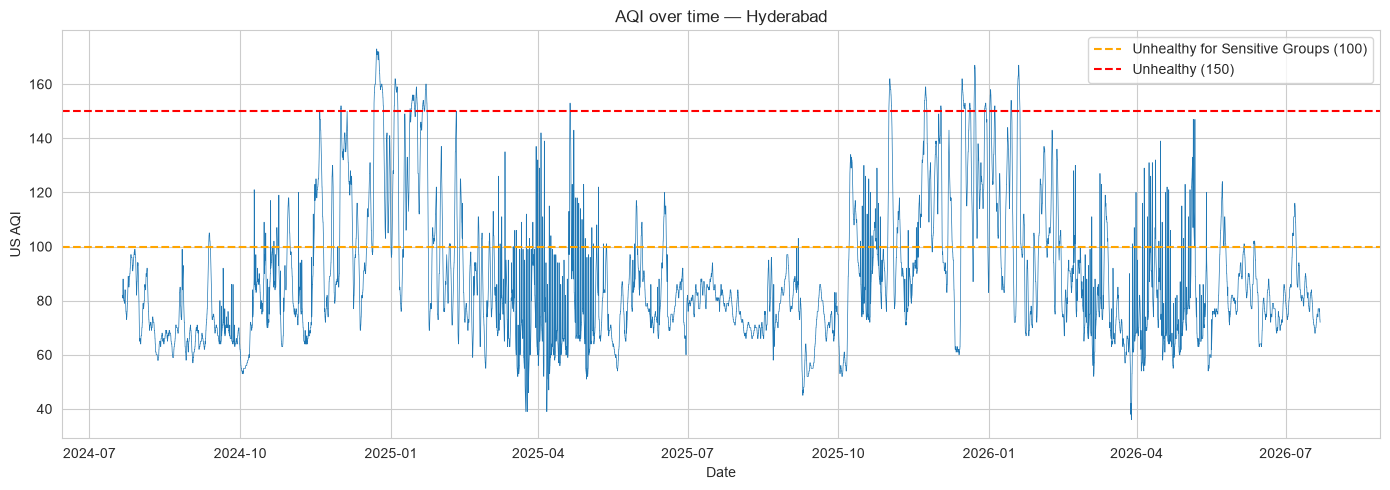

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["aqi"], linewidth=0.5)
plt.title(f"AQI over time — {config.CITY_NAME}")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=100, color="orange", linestyle="--", label="Unhealthy for Sensitive Groups (100)")
plt.axhline(y=150, color="red", linestyle="--", label="Unhealthy (150)")
plt.legend()
plt.tight_layout()
plt.show()

### Cell 7: AQI distribution by month

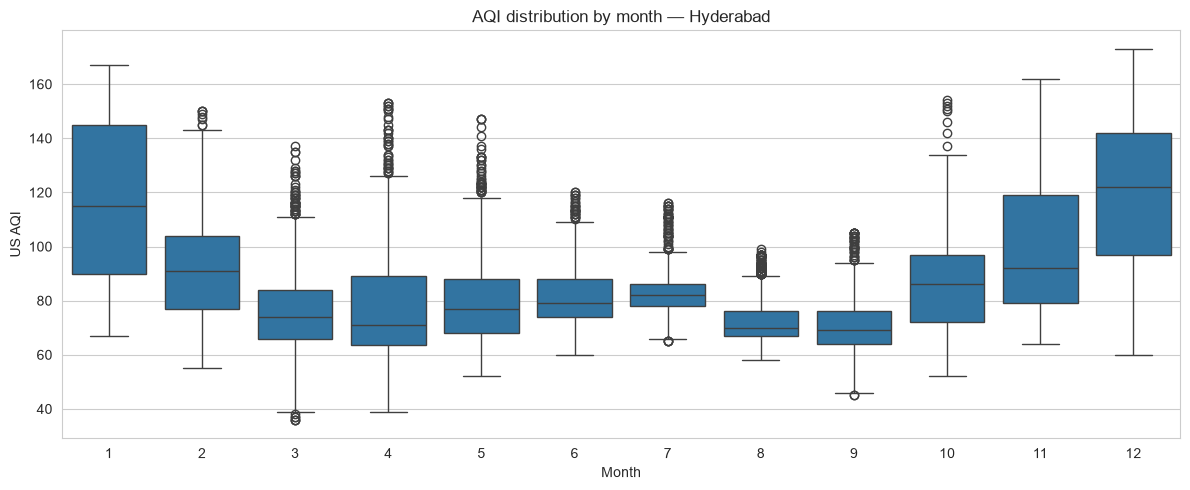

In [14]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="month", y="aqi")
plt.title(f"AQI distribution by month — {config.CITY_NAME}")
plt.xlabel("Month")
plt.ylabel("US AQI")
plt.tight_layout()
plt.show()

### Cell 8: Look at the most extreme rows

In [15]:
df.nlargest(10, "aqi")[["timestamp", "aqi", "pm2_5", "pm10", "co"]]

,timestamp,aqi,pm2_5,pm10,co
3724,2024-12-23 04:00:00,173,82.9,84.8,926.0
3725,2024-12-23 05:00:00,173,79.9,82.4,797.0
3726,2024-12-23 06:00:00,173,76.4,79.4,689.0
3727,2024-12-23 07:00:00,173,77.1,80.6,630.0
3728,2024-12-23 08:00:00,173,71.9,75.4,592.0
3722,2024-12-23 02:00:00,172,86.4,88.7,877.0
3723,2024-12-23 03:00:00,172,87.3,89.6,979.0
3729,2024-12-23 09:00:00,172,65.2,69.4,584.0
3730,2024-12-23 10:00:00,172,61.5,65.9,608.0
3735,2024-12-23 15:00:00,172,98.7,102.2,1271.0


### Cell 9: Correlation heatmap

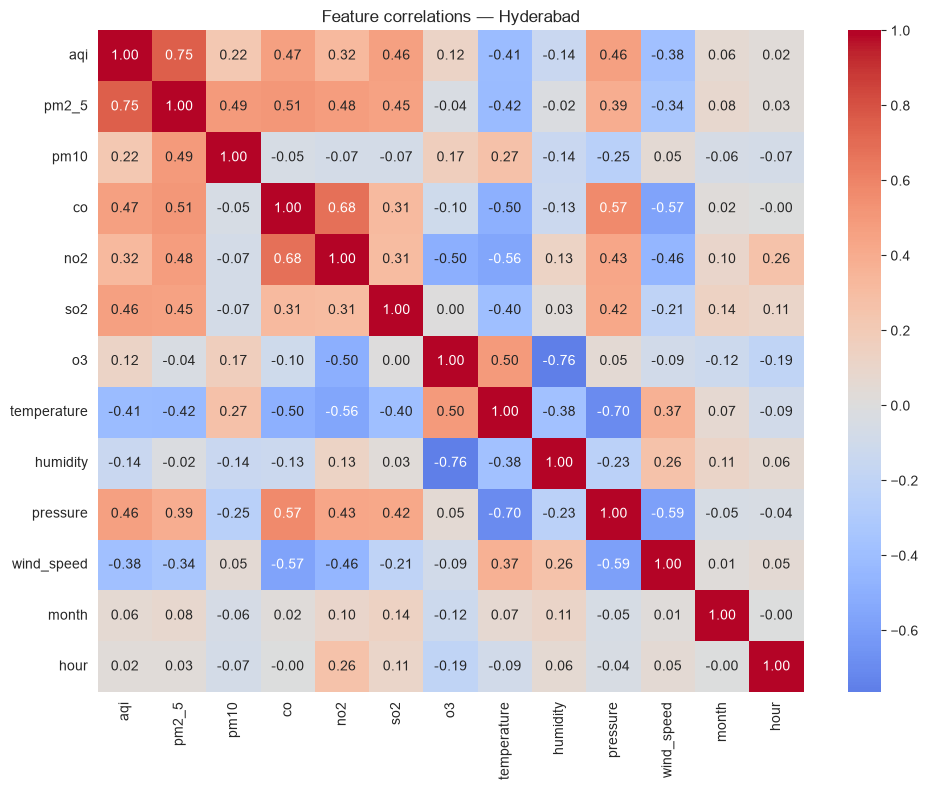

In [16]:
numeric_cols = ["aqi", "pm2_5", "pm10", "co", "no2", "so2", "o3",
                 "temperature", "humidity", "pressure", "wind_speed", "month", "hour"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Feature correlations — {config.CITY_NAME}")
plt.tight_layout()
plt.show()

### Cell 10: AQI by hour of day

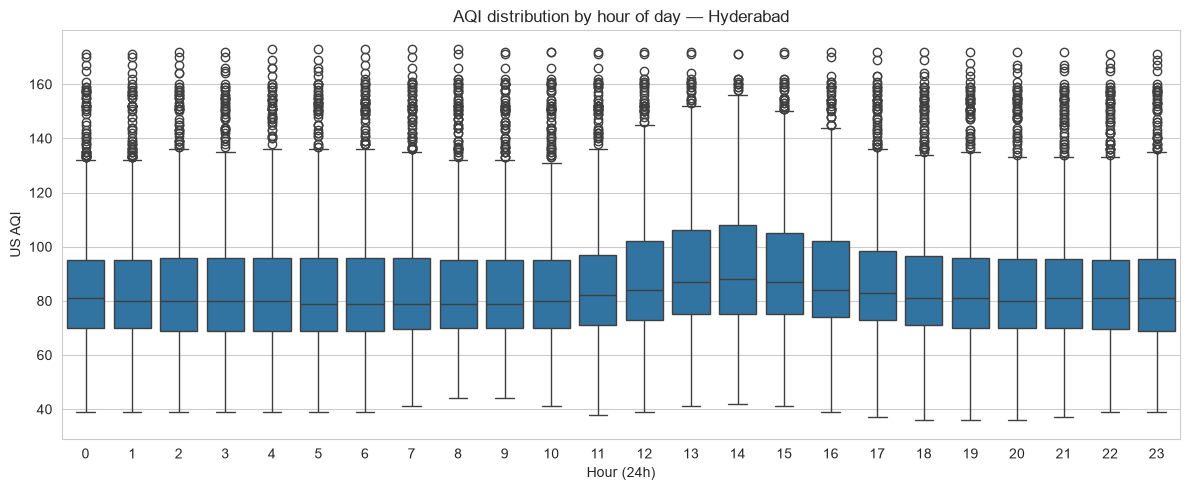

In [17]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="hour", y="aqi")
plt.title(f"AQI distribution by hour of day — {config.CITY_NAME}")
plt.xlabel("Hour (24h)")
plt.ylabel("US AQI")
plt.tight_layout()
plt.show()